In [1]:
!pip install scikit-fuzzy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 29.8 MB/s eta 0:00:00


Recommended green-light duration: 44.24 seconds


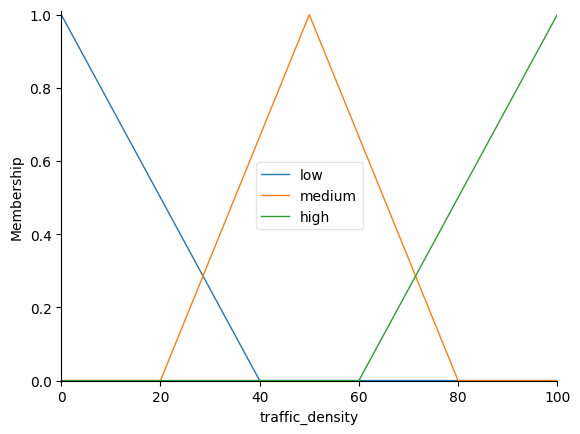

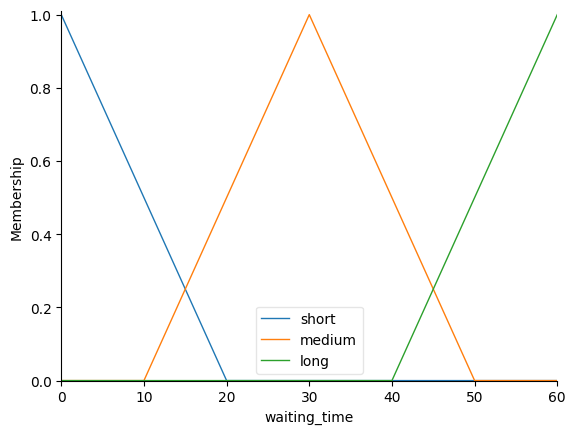

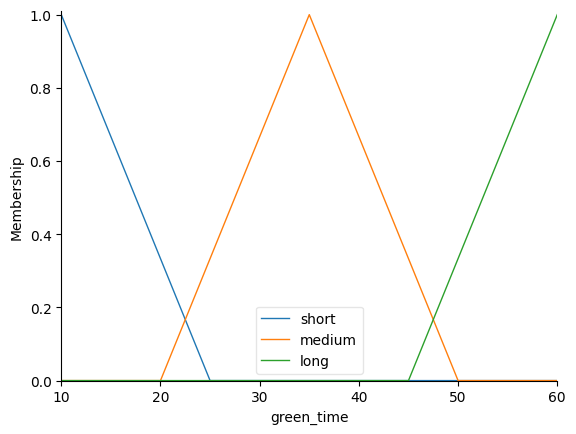

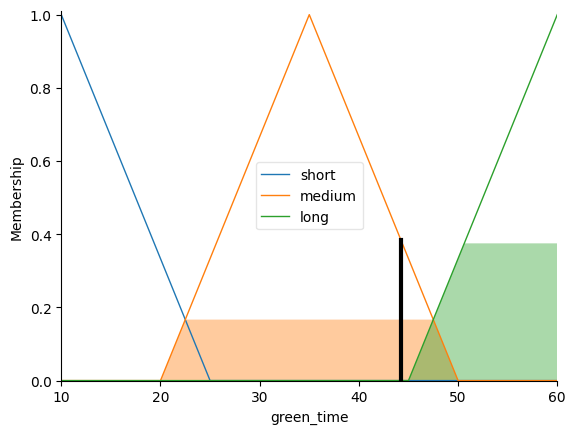

In [2]:
"""
Smart Traffic Signal Control Using Fuzzy Logic
================================================

This example demonstrates how fuzzy logic can be used to determine
the green-light duration at a traffic signal based on traffic
density and vehicle waiting time.
"""

import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl


# Define the input and output variables
traffic_density = ctrl.Antecedent(
    np.arange(0, 101, 1), "traffic_density"
)
waiting_time = ctrl.Antecedent(
    np.arange(0, 61, 1), "waiting_time"
)
green_time = ctrl.Consequent(
    np.arange(10, 61, 1), "green_time"
)


# Define membership functions for traffic density
traffic_density["low"] = fuzz.trimf(
    traffic_density.universe, [0, 0, 40]
)
traffic_density["medium"] = fuzz.trimf(
    traffic_density.universe, [20, 50, 80]
)
traffic_density["high"] = fuzz.trimf(
    traffic_density.universe, [60, 100, 100]
)


# Define membership functions for waiting time
waiting_time["short"] = fuzz.trimf(
    waiting_time.universe, [0, 0, 20]
)
waiting_time["medium"] = fuzz.trimf(
    waiting_time.universe, [10, 30, 50]
)
waiting_time["long"] = fuzz.trimf(
    waiting_time.universe, [40, 60, 60]
)


# Define membership functions for green-light duration
green_time["short"] = fuzz.trimf(
    green_time.universe, [10, 10, 25]
)
green_time["medium"] = fuzz.trimf(
    green_time.universe, [20, 35, 50]
)
green_time["long"] = fuzz.trimf(
    green_time.universe, [45, 60, 60]
)


# Define the fuzzy rules
rule1 = ctrl.Rule(
    traffic_density["low"] & waiting_time["short"],
    green_time["short"]
)

rule2 = ctrl.Rule(
    traffic_density["low"] & waiting_time["medium"],
    green_time["short"]
)

rule3 = ctrl.Rule(
    traffic_density["low"] & waiting_time["long"],
    green_time["medium"]
)

rule4 = ctrl.Rule(
    traffic_density["medium"] & waiting_time["short"],
    green_time["medium"]
)

rule5 = ctrl.Rule(
    traffic_density["medium"] & waiting_time["medium"],
    green_time["medium"]
)

rule6 = ctrl.Rule(
    traffic_density["medium"] & waiting_time["long"],
    green_time["long"]
)

rule7 = ctrl.Rule(
    traffic_density["high"] & waiting_time["short"],
    green_time["medium"]
)

rule8 = ctrl.Rule(
    traffic_density["high"] & waiting_time["medium"],
    green_time["long"]
)

rule9 = ctrl.Rule(
    traffic_density["high"] & waiting_time["long"],
    green_time["long"]
)


# Create the fuzzy control system
traffic_control = ctrl.ControlSystem(
    [
        rule1,
        rule2,
        rule3,
        rule4,
        rule5,
        rule6,
        rule7,
        rule8,
        rule9,
    ]
)

traffic_simulation = ctrl.ControlSystemSimulation(traffic_control)


# Example traffic conditions
traffic_simulation.input["traffic_density"] = 75
traffic_simulation.input["waiting_time"] = 40

traffic_simulation.compute()


print(
    "Recommended green-light duration: "
    f"{traffic_simulation.output['green_time']:.2f} seconds"
)


# Visualize the membership functions
traffic_density.view()
waiting_time.view()
green_time.view()

plt.show()


# Visualize the result for the example input
green_time.view(sim=traffic_simulation)
plt.show()

In [3]:
# Test the fuzzy traffic signal controller with different conditions

test_cases = [
    (20, 5),
    (50, 25),
    (75, 40),
    (95, 55)
]

for density, wait in test_cases:
    simulation = ctrl.ControlSystemSimulation(traffic_control)

    simulation.input["traffic_density"] = density
    simulation.input["waiting_time"] = wait

    simulation.compute()

    print(
        f"Traffic density: {density}% | "
        f"Waiting time: {wait}s | "
        f"Recommended green time: "
        f"{simulation.output['green_time']:.2f}s"
    )

Traffic density: 20% | Waiting time: 5s | Recommended green time: 15.83s
Traffic density: 50% | Waiting time: 25s | Recommended green time: 35.00s
Traffic density: 75% | Waiting time: 40s | Recommended green time: 44.24s
Traffic density: 95% | Waiting time: 55s | Recommended green time: 54.75s


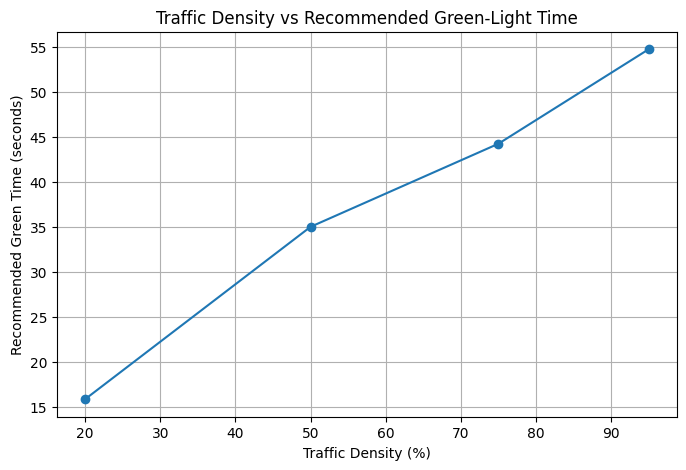

In [4]:
# Plot traffic density vs recommended green-light time

densities = [20, 50, 75, 95]
green_times = [15.83, 35.00, 44.24, 54.75]

plt.figure(figsize=(8, 5))
plt.plot(densities, green_times, marker='o')

plt.xlabel("Traffic Density (%)")
plt.ylabel("Recommended Green Time (seconds)")
plt.title("Traffic Density vs Recommended Green-Light Time")
plt.grid(True)

plt.show()

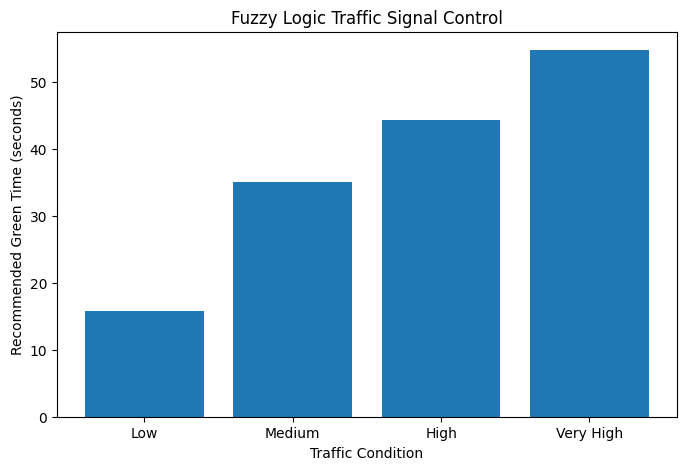

In [5]:
# Test different traffic conditions

test_cases = [
    (20, 5),
    (50, 25),
    (75, 40),
    (95, 55)
]

results = []

for density, wait in test_cases:
    simulation.input["traffic_density"] = density
    simulation.input["waiting_time"] = wait
    simulation.compute()

    green_time = simulation.output["green_time"]
    results.append(green_time)

plt.figure(figsize=(8, 5))

labels = ["Low", "Medium", "High", "Very High"]

plt.bar(labels, results)

plt.xlabel("Traffic Condition")
plt.ylabel("Recommended Green Time (seconds)")
plt.title("Fuzzy Logic Traffic Signal Control")

plt.show()